Ouvertur fichier mise dans dictionnaire toutes les données

In [15]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import os
import matplotlib.cm as cm
from datetime import datetime
from matplotlib import colormaps
import matplotlib.colors as mcolors
import cProfile 
from collections import OrderedDict
import re
import math
from scipy.integrate import simps
from matplotlib.ticker import FuncFormatter

def extraire_numero(cle):
    # Extraire la partie numérique de la clé
    return int(cle.split('_')[2].split('.')[0])

def open_data (file_path : str, sample_name : str, data_path_XRF : str, data_path_time : str, data_path_z : str, srcur_path : str ) -> dict : # path without the file name
    
    data = {}
    
    os.chdir(file_path) # path changing
    file = h5py.File(sample_name, "r") # file opening
    scans_name= list(file.keys()) # take name of the scans
    
    data_paths_XRF = [scan_name + data_path_XRF for scan_name in scans_name] # create the path for accessing to the data 
    data_paths_time = [scan_name + data_path_time for scan_name in scans_name]
    data_paths_z = [scan_name + data_path_z for scan_name in scans_name]
    srcur_paths = [scan_name + srcur_path for scan_name in scans_name]
    
    for data_path_XRF, scan_name, data_path_time, data_path_z, srcur_path  in zip(data_paths_XRF, scans_name, data_paths_time, data_paths_z, srcur_paths) :
        if file.get(data_path_XRF) and file.get(data_path_z) and file.get(data_path_time) : # condition if data_path exist
            
            data_time = file [data_path_time][:]
            data_z = file [data_path_z][:]
            data_XRF = file [data_path_XRF][:]
            srcur = file[srcur_path][:][:, np.newaxis]
            data [scan_name] = {
                'time' : data_time, 
                'z_position' : data_z,
                'intensity' : data_XRF, 
                'srcur' : srcur
            }

            data [scan_name]["XRF"] = data[scan_name]["intensity"] / data[scan_name]["srcur"]
            
        else:
            data_paths = [path for path in data_paths_XRF if path != data_path_XRF]
           
    return data


data = open_data ("/home/esrf/pauline2a/ma6562/id31/20250509/RAW_DATA/X1/","ma6562_X1.h5", "/measurement/fx_det0/","/measurement/epoch/" ,"/measurement/h1tz/", "/measurement/srcur/" )



In [2]:
data = open_data ("/home/esrf/pauline2a/ma6562/id31/20250509/RAW_DATA/X7/","ma6562_X7.h5", "/measurement/fx_det0/","/measurement/epoch/" ,"/measurement/h1tz/","/measurement/srcur/")
keys = data.keys()
n_ligne_tot = []
for key in keys :
    
    array = data[key]["XRF"]
 
    n_lignes = array.shape[0]
    n_ligne_tot.append (n_lignes)
print (n_ligne_tot)
print (sum(n_ligne_tot))


[34, 34, 34, 34, 34, 34, 800, 34, 34, 25, 19, 19, 41, 41, 41, 41, 41, 800, 184, 800, 34, 34, 34, 34, 34, 34, 34, 41, 34, 34, 34, 34, 34, 34, 34, 34, 34, 34, 31, 9, 800, 34, 34, 34, 34, 34, 34, 34, 34, 31, 34, 34, 34, 34, 34, 34, 34, 34, 34, 34, 34, 34, 34, 34, 34, 800, 34, 34, 34, 34, 34, 8, 800, 34, 34, 34, 34, 34, 34, 34, 34, 34, 34, 800, 34, 34, 34, 34, 34, 34, 34, 34, 34, 34, 34, 34, 34, 34, 34, 34]
8858


calcul moyenne et fonctioin de ligne de base

In [3]:
def average_value (min_value : int, max_value : int, y_values : list) -> float:
    x_points = list(range(min_value, max_value ))
    y = []
    for x_point in x_points :
            y.append(y_values[x_point])
            
    average = sum(y)/(len(x_points)) 
    return average

def baseline (x1_min, x1_max,x2_min, x2_max, data_list) -> list:
    y_list=[]
    y_baseline = []
    y_data = []
    
    y1 = average_value(x1_min,x1_max, data_list)
    y2 = average_value(x2_min,x2_max, data_list)
    x_list= np.array([[(x1_min+x1_max)/2, 1], 
                      [(x2_min+x2_max)/2, 1]])
    y_system = np.array([y1, y2])
    x_segment = np.arange(x1_min, x2_max + 1)
    a, b = np.linalg.solve(x_list,y_system)
    for x in x_segment :
        yp = a*x+b
        y_baseline.append(yp)
        y_data.append (data_list[x]) 
    y_baseline_np = np.array (y_baseline)
    y_data_np = np.array(y_data)
    y_correct = y_data_np-y_baseline_np
    return y_baseline, x_segment, y_correct



Fonction convertis temps linux en temps relatif en heure attention changer la valeur du o relatif

In [4]:
data = open_data ("/home/esrf/pauline2a/ma6562/id31/20250509/RAW_DATA/X1/","ma6562_X1.h5", "/measurement/fx_det0/","/measurement/epoch/" ,"/measurement/h1tz/","/measurement/srcur/")

def min_time_value_calc (data : dict, ) -> float:
    for key in data.keys():
        min_vals = []
        if "time" in data[key]: 
            min_val = np.min(data[key]["time"])
            min_vals.append(min_val)
    min_valu= min( min_vals)
    return min_valu
    
def relative_time (time_values : np.ndarray, data : dict) -> np.ndarray :
    relative_time_values = []
    for time in time_values :
        relative_time_value = (time - 1746806596.06)/3600
        relative_time_values. append (relative_time_value)
    return relative_time_values



creation dictionnaire avec que donne avec ligne de base et celle avec une intensite trop faible

In [5]:


def data_baseline (file_path : str, sample_name : str, data_path : str, data_path_time : str, data_path_z : str, srcur_path):
    i=0
    data_baseline = {}
    data = open_data (file_path, sample_name, data_path, data_path_time, data_path_z,srcur_path )
    for key in data.keys() : 
        values = data.get(key, {}).get("XRF", [])
        lines_numb = values.shape[0] -1 
        Ir63_list = []
        Ir64_list = []
        Ir73_list = []
        Pt75_list = []
        time_values = []
        z_values = []
        for line in range (lines_numb) :
            lines = data[key]["XRF"][line]
            if np.max(lines) > 1 : 
                y_Ir63, x_Ir63, y_corrected_Ir63 = baseline (3090, 3094, 3195, 3199, lines)
                Ir63_list.append(y_corrected_Ir63)
                Ir63_table = np.array(Ir63_list)
    
                y_Ir64, x_Ir64, y_corrected_Ir64 = baseline (3200, 3204, 3290, 3294, lines)
                Ir64_list.append(y_corrected_Ir64)
                Ir64_table = np.array(Ir64_list)
                
                y_Ir73, x_Ir73, y_corrected_Ir73 = baseline (3575, 3579,3725, 3729, lines)
                Ir73_list.append(y_corrected_Ir73)
                Ir73_table = np.array(Ir73_list)
                
                y_Pt75, x_Pt75, y_corrected_Pt75 = baseline (3735, 3739,3830, 3834, lines)
                Pt75_list.append(y_corrected_Pt75)
                Pt75_table = np.array(Pt75_list)
                
                time_value = data[key]["time"][line]
                time_values.append(time_value)  
                times_values_table = np.array(time_values)
                relatives_time= relative_time(times_values_table, data)
                
                
                z_value = data[key]["z_position"][line]
                z_values.append(z_value) 
                
                data_baseline [key] = {
                    "Ir63" : {
                        "relative_time" : relatives_time, 
                        "z_position" : z_values, 
                        "y_corrected" : Ir63_table
                        
                    },
                    "Ir64" : {
                 
                         "relative_time" : relatives_time, 
                        "z_position" : z_values,
                        "y_corrected" : Ir64_table
                        
                    },
                    "Ir73" : {
            
                         "relative_time" : relatives_time, 
                        "z_position" : z_values,
                        "y_corrected" : Ir73_table
                        
                    },
                    "Pt75" : {
                
                         "relative_time" : relatives_time, 
                        "z_position" : z_values,
                        "y_corrected" : Pt75_table
                        
                    }
                }
                
    data_baseline ["x_index"] = { 
        "Ir63_index" : x_Ir63,
        "Ir64_index" : x_Ir64,  
        "Ir73_index" : x_Ir73,
        "Pt75_index" : x_Pt75
    }
    Ir63_index = data_baseline ["x_index"]["Ir63_index"]
    Ir64_index = data_baseline ["x_index"]["Ir64_index"]
    Ir73_index = data_baseline ["x_index"]["Ir73_index"]
    Pt75_index = data_baseline ["x_index"]["Pt75_index"]

    Ir63_energy = Ir63_index*0.02
    Ir64_energy = Ir64_index*0.02
    Ir73_energy = Ir73_index*0.02
    Pt75_energy = Pt75_index*0.02

    data_baseline ["energy"] = { 
        "Ir63" : Ir63_energy,
        "Ir64" : Ir64_energy,  
        "Ir73" : Ir73_energy,
        "Pt75" : Pt75_energy
    }
    
    return data_baseline
# cProfile.run('data_baseline("/home/esrf/pauline2a/ma6562/id31/20250509/RAW_DATA/X1/","ma6562_X1.h5", "/measurement/fx_det0/","/measurement/epoch/" ,"/measurement/h1tz/" )')

data_baselines = data_baseline ("/home/esrf/pauline2a/ma6562/id31/20250509/RAW_DATA/X1/","ma6562_X1.h5", "/measurement/fx_det0/","/measurement/epoch/" ,"/measurement/h1tz/","/measurement/srcur/")


fonction range cle par ordre 

In [6]:
def arrange_keys(keys):
    # Ne garder que les clés au bon format
    valid_keys = [k for k in keys if re.search(r'_(\d+)\.', k)]

    # Trier les clés valides par le nombre extrait
    sorted_keys = sorted(valid_keys, key=lambda k: int(re.search(r'_(\d+)\.', k).group(1)))

    # Extraire les numéros des scans
    scan_numb = [int(re.search(r'_(\d+)\.', key).group(1)) for key in sorted_keys]
    
    return sorted_keys, scan_numb

data_baselines = data_baseline ("/home/esrf/pauline2a/ma6562/id31/20250509/RAW_DATA/X1/","ma6562_X1.h5", "/measurement/fx_det0/","/measurement/epoch/" ,"/measurement/h1tz/","/measurement/srcur/")

Integration des 4 pics, Ir63, Ir64, Ir73, Pt75

In [7]:
cmap = colormaps ['viridis']
data = open_data ("/home/esrf/pauline2a/ma6562/id31/20250509/RAW_DATA/X1/","ma6562_X1.h5", "/measurement/fx_det0/","/measurement/epoch/" ,"/measurement/h1tz/", "/measurement/srcur/" )
data_baselines = data_baseline ("/home/esrf/pauline2a/ma6562/id31/20250509/RAW_DATA/X1/","ma6562_X1.h5", "/measurement/fx_det0/","/measurement/epoch/" ,"/measurement/h1tz/","/measurement/srcur/")

def integration (data_baselines) :
    keys_messy = []
    for key in data_baselines.keys():
        keys_messy.append(key)
    ordered_keys, scan_numb = arrange_keys(keys_messy)

    spectra_names = ["Ir63", "Ir64", "Ir73", "Pt75"]
    for scan_name in ordered_keys : 
        if "Ir63" in data_baselines [scan_name]:
            for spectra_name in spectra_names :
                energy = data_baselines['energy'][spectra_name]
                area_spectra_name = []
                for line in data_baselines[scan_name][spectra_name]["y_corrected"] :
                    area = simps(line)
                   
                    area_spectra_name.append(area)

                data_baselines[scan_name][spectra_name]["integration"] = area_spectra_name
    return data_baselines           
data_baselines = integration (data_baselines)       


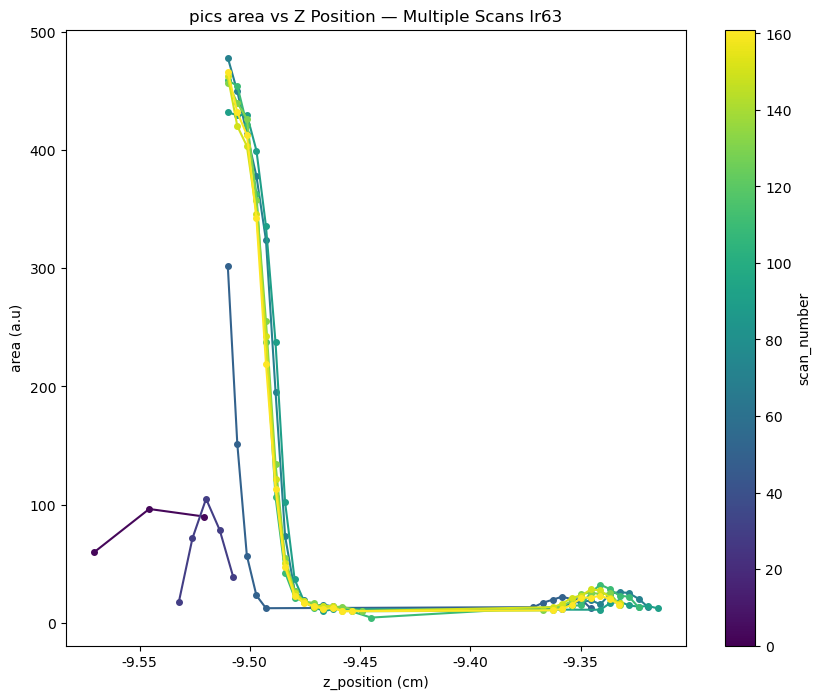

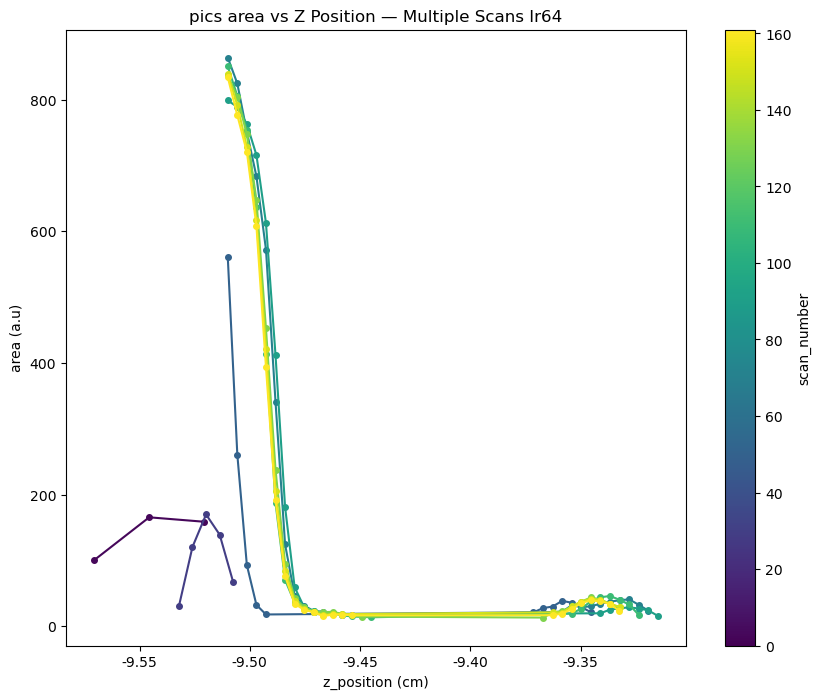

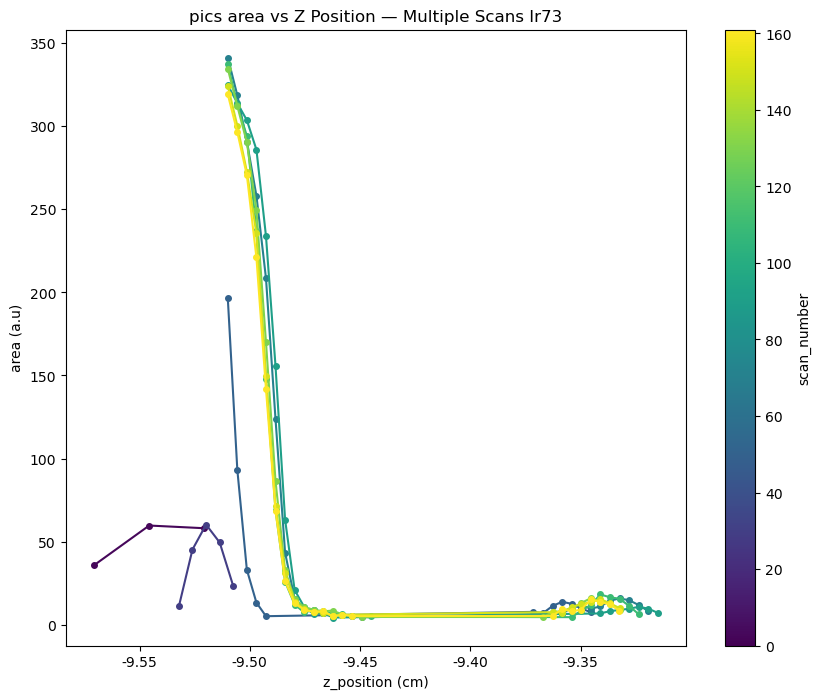

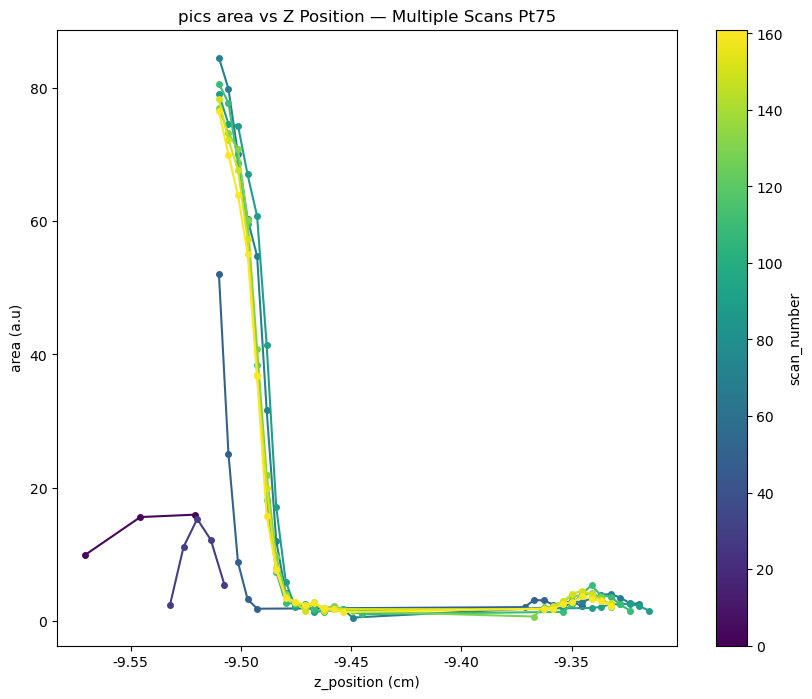

In [8]:
cmap = colormaps ['viridis']
data = open_data ("/home/esrf/pauline2a/ma6562/id31/20250509/RAW_DATA/X1/","ma6562_X1.h5", "/measurement/fx_det0/","/measurement/epoch/" ,"/measurement/h1tz/", "/measurement/srcur/" )
data_base = data_baseline ("/home/esrf/pauline2a/ma6562/id31/20250509/RAW_DATA/X1/","ma6562_X1.h5", "/measurement/fx_det0/","/measurement/epoch/" ,"/measurement/h1tz/","/measurement/srcur/")
data_baselines = integration (data_base)
keys_messy = []

for key in data_baselines.keys():
        keys_messy.append(key)
ordered_keys, scan_numb = arrange_keys(keys_messy)
keys = []
scan_numb_red = []
for i in range (0, len(ordered_keys), 20):
    keys.append(ordered_keys[i])
    scan_numb_red.append (scan_numb[i])  


spectras_name = ["Ir63", "Ir64", "Ir73", "Pt75"]
for specra_name in spectras_name :  
    fig, ax = plt.subplots(figsize = (10,8))
    norm = mcolors.Normalize(vmin=0, vmax = (len (data_baselines) -6))
    cmap = cm.viridis
    for scan_numbe, key in zip(scan_numb_red ,keys):
        color = cmap(scan_numbe / (len (ordered_keys) -2))
        if "Ir63" in data_baselines[key]:
            area = data_baselines[key][specra_name]["integration"]
            # print (area)
            z_position = data_baselines[key][specra_name]["z_position"]
            plt.plot ( z_position,area, color=cmap(norm(scan_numbe)),  label = key, marker='o', markersize=4 )
            
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])  
    fig.colorbar(sm, ax=ax, label='scan_number')  
    plt.title(f"pics area vs Z Position — Multiple Scans {specra_name}")
    plt.xlabel("z_position (cm)")
    plt.ylabel("area (a.u)")
    # plt.xlim(-9.38, -9.305)
    formatter = FuncFormatter(lambda x, _: f'{x:.2f}')
    ax.xaxis.set_major_formatter(formatter)
   
    # plt.ylim(-0.4,50)
    plt.show()

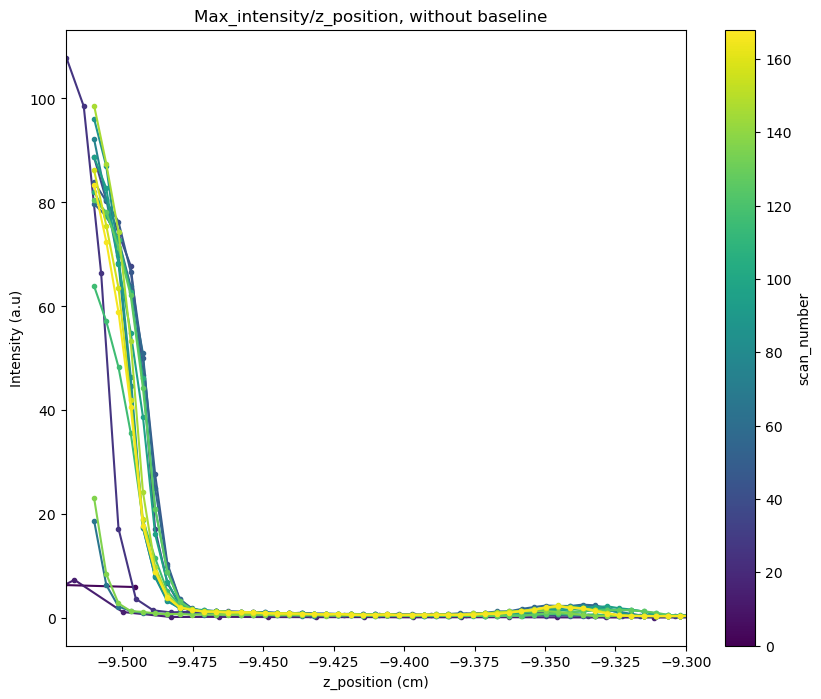

In [9]:
cmap = colormaps ['viridis']
data = open_data ("/home/esrf/pauline2a/ma6562/id31/20250509/RAW_DATA/X1/","ma6562_X1.h5", "/measurement/fx_det0/","/measurement/epoch/" ,"/measurement/h1tz/", "/measurement/srcur/" )
data_baselines = data_baseline ("/home/esrf/pauline2a/ma6562/id31/20250509/RAW_DATA/X1/","ma6562_X1.h5", "/measurement/fx_det0/","/measurement/epoch/" ,"/measurement/h1tz/","/measurement/srcur/")

keys = []
keys_messy = []
scan_numb_red = []
for key in data.keys():
    keys_messy.append(key)
ordered_keys, scan_numb = arrange_keys(keys_messy)

for i in range (0, len(ordered_keys)-1, 10):
    keys.append(ordered_keys[i])
    scan_numb_red.append (scan_numb[i])  

# fig, ax = plt.subplots(figsize = (10,8))
# norm = mcolors.Normalize(vmin=0, vmax = (len (ordered_keys) -1))
# cmap = cm.viridis

# for scan_numb, key in zip (scan_numb_red, keys):

#     max_lines = []
#     color = cmap(scan_numb / (len(ordered_keys) - 1))
#     for i in range(len (data[key]["XRF"])) : 
#         max_line = max(data[key]["XRF"][i])
#         max_lines.append(max_line)

#     z_position = data[key]["z_position"]
#     plt.plot(z_position, max_lines, color=color,  marker = 'o', markersize = 3  )
    
# plt.xlim(-9.4,-9.3)
# plt.ylim(0, 5)
# plt.title ("Max_intensity/z_position, without baseline  ")
# plt.xlabel("z_position (cm)")
# plt.ylabel("Intensity (a.u)")
# sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
# sm.set_array([]) 
# fig.colorbar(sm, ax=ax, label='scan_number')  
# plt.show()


# fig, ax = plt.subplots(figsize = (10,8))
# norm = mcolors.Normalize(vmin=0, vmax = (len (ordered_keys) -1))


# for scan_numb, key in zip (scan_numb_red, keys):

#     max_lines = []
#     color = cmap(scan_numb / (len(ordered_keys) - 1))
#     for i in range(len (data[key]["XRF"])) : 
#         max_line = max(data[key]["XRF"][i])
#         max_lines.append(max_line)

#     z_position = data[key]["z_position"]
#     plt.plot(z_position, max_lines, color=color , marker = 'o', markersize = 3  )
# plt.xlim(-9.52,-9.475)
# # plt.ylim(0, 5)
# plt.title ("Max_intensity/z_position, without baseline  ")
# plt.xlabel("z_position (cm)")
# plt.ylabel("Intensity (a.u)")
# sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
# sm.set_array([]) 
# fig.colorbar(sm, ax=ax, label='scan_number')  
# plt.show()



fig, ax = plt.subplots(figsize = (10,8))
norm = mcolors.Normalize(vmin=0, vmax = (len (ordered_keys) -1))


for scan_numb, key in zip (scan_numb_red, keys):

    max_lines = []
    color = cmap(scan_numb / (len(ordered_keys) - 1))
    for i in range(len (data[key]["XRF"])) : 
        max_line = max(data[key]["XRF"][i])
        max_lines.append(max_line)

    z_position = data[key]["z_position"]
    plt.plot(z_position, max_lines, color=color , marker = 'o', markersize = 3  )
plt.xlim(-9.52,-9.3)
# plt.ylim(0, 5)
plt.title ("Max_intensity/z_position, without baseline  ")
plt.xlabel("z_position (cm)")
plt.ylabel("Intensity (a.u)")
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([]) 
fig.colorbar(sm, ax=ax, label='scan_number')  
plt.show()



In [10]:
def afficher_clés(d):
    for key, value in d.items():
        if isinstance(value, dict):  # Si la valeur est un dictionnaire
            print(f"Clé: {key}")
            afficher_clés(value)  # Appel récursif pour afficher les sous-clés
        else:
            print(f"Clé: {key} -> Valeur: {value}")

NameError: name 'index' is not defined

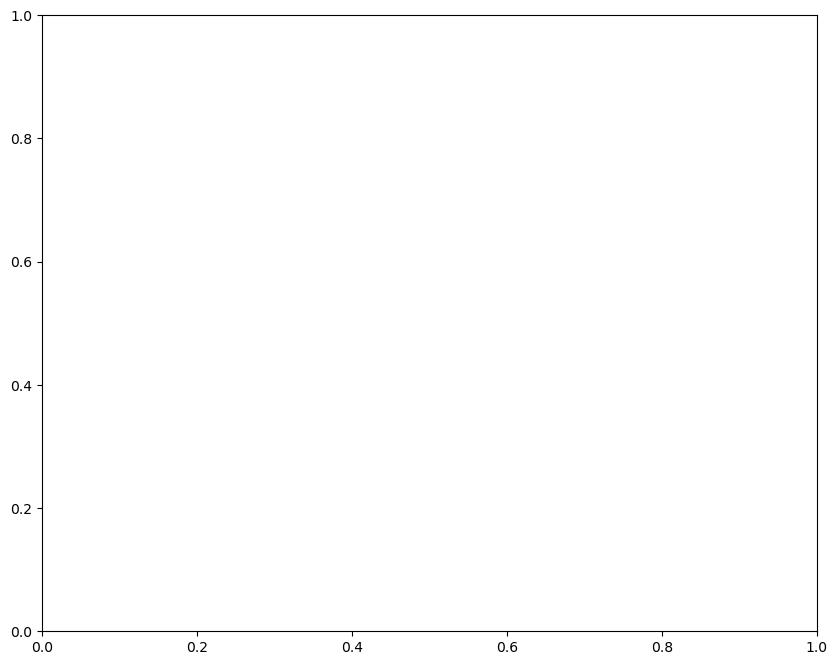

In [11]:


cmap = colormaps ['viridis']
data = open_data ("/home/esrf/pauline2a/ma6562/id31/20250509/RAW_DATA/X1/","ma6562_X1.h5", "/measurement/fx_det0/","/measurement/epoch/" ,"/measurement/h1tz/", "/measurement/srcur/" )
data_baselines = data_baseline ("/home/esrf/pauline2a/ma6562/id31/20250509/RAW_DATA/X1/","ma6562_X1.h5", "/measurement/fx_det0/","/measurement/epoch/" ,"/measurement/h1tz/","/measurement/srcur/")
              
keys = []
scan_numb_red = []

keys_messy = data_baselines.keys()     

ordered_keys, scan_numb = arrange_keys(keys_messy)

for i in range (0, len(ordered_keys), 10):
    keys.append(ordered_keys[i])
    scan_numb_red.append (scan_numb[i])  
# print (keys, scan_numb_red) 

# fig, ax = plt.subplots(figsize = (10,8))
# norm = mcolors.Normalize(vmin=0, vmax=len(ordered_keys) - 1)
# cmap = cm.viridis

# for scan_numb, key in zip(scan_numb_red,keys):
#     if "Ir63" in data_baselines[key]:
#         max_lines = []
#         color = cmap(scan_numb / (len(ordered_keys) - 1))
       
#         for line in data_baselines[key]["Ir64"]["y_corrected"] : 
#             max_line = max(line)
#             max_lines.append(max_line)
#         z_position = data_baselines[key]['Ir64']["z_position"]
#         ax.plot(z_position, max_lines , color=cmap(norm(scan_numb)), label=f'Courbe {index+1}', marker = 'o', markersize = 3)
    
# sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
# sm.set_array([])  
# plt.xlim(-9.4,-9.3)
# plt.ylim(0, 3)
# fig.colorbar(sm, ax=ax, label='scan_number')    
# plt.title ("Max_intensity/z_position, with baseline , Ir64  ")
# plt.xlabel("z_position (cm)")
# plt.ylabel("Intensity (a.u)")
# plt.show()

# fig, ax = plt.subplots(figsize = (10,8))
# norm = mcolors.Normalize(vmin=0, vmax=len(ordered_keys) - 1)
# cmap = cm.viridis

# for scan_numb, key in zip(scan_numb_red,keys):
#     if "Ir64" in data_baselines[key]:
#         max_lines = []
#         color = cmap(scan_numb / (len(ordered_keys) - 1))
       
#         for line in data_baselines[key]["Ir64"]["y_corrected"] : 
#             max_line = max(line)
#             max_lines.append(max_line)
#         z_position = data_baselines[key]['Ir64']["z_position"]
#         ax.plot(z_position, max_lines , color=cmap(norm(scan_numb)), label=f'Courbe {index+1}', marker = 'o', markersize = 3)
    
# sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
# sm.set_array([]) 
# plt.title ("Max_intensity/z_position, with baseline , Ir64  ")
# plt.xlabel("z_position (cm)")
# plt.ylabel("Intensity (a.u)")
# plt.xlim(-9.52,-9.475)
# fig.colorbar(sm, ax=ax, label='scan_number')    
# plt.show()


fig, ax = plt.subplots(figsize = (10,8))
norm = mcolors.Normalize(vmin=0, vmax=len(ordered_keys) - 1)
cmap = cm.viridis

for scan_numb, key in zip(scan_numb_red,keys):
    if "Ir64" in data_baselines[key]:
        max_lines = []
        color = cmap(scan_numb / (len(ordered_keys) - 1))
       
        for line in data_baselines[key]["Ir64"]["y_corrected"] : 
            max_line = max(line)
            max_lines.append(max_line)
        z_position = data_baselines[key]['Ir64']["z_position"]
        ax.plot(z_position, max_lines , color=cmap(norm(scan_numb)), label=f'Courbe {index+1}', marker = 'o', markersize = 3)
    
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([]) 
plt.title ("Max_intensity/z_position, with baseline , Ir64  ")
plt.xlabel("z_position (cm)")
plt.ylabel("Intensity (a.u)")
plt.xlim(-9.4,-9.3)
fig.colorbar(sm, ax=ax, label='scan_number')    
plt.show()


In [ ]:
# cmap = colormaps ['viridis']
# data = data_baseline ("/home/esrf/pauline2a/ma6562/id31/20250509/RAW_DATA/X1/","ma6562_X1.h5", "/measurement/fx_det0/","/measurement/epoch/" ,"/measurement/h1tz/","/measurement/srcur/")   
# energy = data_baselines ["energy"]["Ir63"]
# scan_names = [f"X1_0001_{i}.1" for i in range(40, 171, 10)]
# ordered_keys, scan_numb = arrange_keys(scan_names)
# plt.figure(figsize=(10, 6))
# for index, scan_name in enumerate (scan_names) :
#     if scan_name in data:    
#         color = cmap(index / (len(scan_names) - 1))
#         intensity = data_baselines[scan_name]["Ir63"]["y_corrected"][0]

#         plt.plot(energy, intensity, color = color, label=f'temps {index+1}' )

# for scan_name in scan_names :
#     intensity = data_baselines[scan_name]["Ir63"]["y_corrected"][0]
#     plt.plot(energy, intensity, label ="X1_0001_{i}.1" )

# plt.legend()
# plt.show()

In [ ]:
cmap = colormaps ['viridis']
data = open_data ("/home/esrf/pauline2a/ma6562/id31/20250509/RAW_DATA/X1/","ma6562_X1.h5", "/measurement/fx_det0/","/measurement/epoch/" ,"/measurement/h1tz/", "/measurement/srcur/" )
data_baselines = data_baseline ("/home/esrf/pauline2a/ma6562/id31/20250509/RAW_DATA/X1/","ma6562_X1.h5", "/measurement/fx_det0/","/measurement/epoch/" ,"/measurement/h1tz/","/measurement/srcur/")
# scan_numb = (len (data_baselines) -6)

scan_names = list(data_baselines.keys())
ordered_keys, scan_numb = arrange_keys(scan_names)

keys = []
scan_numb_red = []
test= []
for i in range (0, len(ordered_keys), 10):
    keys.append(ordered_keys[i])
    scan_numb_red.append (scan_numb[i])  

norm = mcolors.Normalize(vmin=0, vmax = (len (data_baselines) -6))
cmap = cm.viridis
spectras_name = ["Ir63", "Ir64", "Ir73", "Pt75"]
for specra_name in spectras_name :  
    fig, ax = plt.subplots()

    for scan_numbe, key in zip(scan_numb_red ,keys):
        
        color = cmap(scan_numbe / (len (data_baselines) -6))
        if "Ir63" in data_baselines[key]:
            max_lines = np.max(data_baselines[key][specra_name]["y_corrected"], axis=1)
            z_position = data_baselines[key][specra_name]["z_position"]
            test.append(max_lines)
            plt.plot ( z_position,max_lines, color=cmap(norm(scan_numbe)),  label = key, marker='o', markersize=3 )
            
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])  
    fig.colorbar(sm, ax=ax, label='scan_number')  
    plt.title(f"Max Intensity vs Z Position — Multiple Scans {specra_name}")
    plt.xlabel("z_position (cm)")
    plt.ylabel("intensity (a.u)")
    # plt.xlim(-9.4, -9.3)
    formatter = FuncFormatter(lambda x, _: f'{x:.2f}')
    ax.xaxis.set_major_formatter(formatter)
    # ax.yaxis.set_major_formatter(formatter)
    plt.xlim(-9.4,-9.3)
    plt.ylim(0, 3)
    plt.show()


In [ ]:
# cmap = colormaps ['viridis']
# data = open_data ("/home/esrf/pauline2a/ma6562/id31/20250509/RAW_DATA/X1/","ma6562_X1.h5", "/measurement/fx_det0/","/measurement/epoch/" ,"/measurement/h1tz/", "/measurement/srcur/" )
# scan_names = list(data.keys())
# ordered_keys, scan_numb = arrange_keys(scan_names)

# keys = []
# scan_numb_red = []

# for i in range (40, len(ordered_keys), 5):
#     keys.append(ordered_keys[i])
#     scan_numb_red.append (scan_numb[i])  

# fig, ax = plt.subplots(figsize=(10, 7))
# norm = mcolors.Normalize(vmin=0, vmax = (len (data) -6))
# cmap = cm.viridis 
# for scan_numbe, key in zip(scan_numb_red ,keys):

#     color = cmap(scan_numbe / (len (data)-1))
#     max_lines = np.max(data[key]["XRF"], axis=1)
#     z_position = data[key]["z_position"]
#     plt.plot ( z_position,max_lines, color=cmap(norm(scan_numbe)),  label = key, marker='o', markersize=3 )

# sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
# sm.set_array([])  
# fig.colorbar(sm, ax=ax, label='scan_number')  
# plt.title(f"Max Intensity vs Z Position — Multiple Scans, befor baseline")
# plt.xlabel("z_position (cm)")
# plt.ylabel("intensity (a.u)")
# plt.xlim(-9.375, -9.3)
# plt.ylim(0, 5)
# plt.show()

In [ ]:
cmap = colormaps ['viridis']
data = open_data ("/home/esrf/pauline2a/ma6562/id31/20250509/RAW_DATA/X1/","ma6562_X1.h5", "/measurement/fx_det0/","/measurement/epoch/" ,"/measurement/h1tz/", "/measurement/srcur/" )
data_baselines = data_baseline ("/home/esrf/pauline2a/ma6562/id31/20250509/RAW_DATA/X1/","ma6562_X1.h5", "/measurement/fx_det0/","/measurement/epoch/" ,"/measurement/h1tz/","/measurement/srcur/")
# scan_numb = (len (data_baselines) -6)

scan_names = list(data_baselines.keys())
ordered_keys, scan_numb = arrange_keys(scan_names)

keys = []
scan_numb_red = []

for i in range (40,len(ordered_keys) , 10):
    keys.append(ordered_keys[i])
    scan_numb_red.append (scan_numb[i])  


norm = mcolors.Normalize(vmin=0, vmax = (len (ordered_keys) -1))
cmap = cm.viridis
z_positions = [-9.50999, -9.501339, -9.479669, -9.362676, -9.345339, -9.332335]
spectras_name = [
    # "Ir63",
                 # "Ir64",
                 # "Ir73",
                 "Pt75"
                ]

for spectra_name in spectras_name : 
    print ("-----------------------------------------------------------------------------------------------------------------")
    
    for z in z_positions  :
        fig, ax = plt.subplots()
        
        for scan_numb, key in zip(scan_numb_red ,keys) :
            for i, z_position in enumerate(data_baselines[key][spectra_name]["z_position"]):
                if math.isclose(z_position, z, abs_tol=0.0001):
                    energy = data_baselines["energy"][spectra_name]
                    intensity =  data_baselines[key][spectra_name]["y_corrected"][i]
                    color = cmap(scan_numb / (len (ordered_keys)))
                    plt.plot ( energy , intensity, color=cmap(norm(scan_numb)), label = key)
        sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)              
        fig.colorbar(sm, ax=ax, label='scan_number') 
        
        sm.set_array([])
        plt.title(f"Intensity/energy — Multiple Scans, {spectra_name}, z_position {z}")
        plt.xlabel("Energy (KeV)")
        plt.ylabel("intensity (a.u)")
        # plt.legend()
        plt.xlim(74.75, 76.65)
        plt.ylim(-1, 5)
        plt.show()

    

In [ ]:
cmap = colormaps ['viridis']
data = open_data ("/home/esrf/pauline2a/ma6562/id31/20250509/RAW_DATA/X1/","ma6562_X1.h5", "/measurement/fx_det0/","/measurement/epoch/" ,"/measurement/h1tz/", "/measurement/srcur/" )
data_baselines = data_baseline ("/home/esrf/pauline2a/ma6562/id31/20250509/RAW_DATA/X1/","ma6562_X1.h5", "/measurement/fx_det0/","/measurement/epoch/" ,"/measurement/h1tz/","/measurement/srcur/")

scan_names = list(data_baselines.keys())
ordered_keys, scan_numb = arrange_keys(scan_names)

keys = []
scan_numb_red = []

for i in range (50, len(ordered_keys),5):
    keys.append(ordered_keys[i])
    scan_numb_red.append (scan_numb[i])  

z_cell = [-9.50999, -9.501339, -9.479669, -9.362676, -9.345339, -9.332335]
spectras_name = ["Ir63", "Ir64", "Ir73", "Pt75"]
# for z in z_positions  :
vmin = min(z_cell )
vmax = max(z_cell )
norm = mcolors.Normalize(vmin, vmax )
cmap = cm.viridis
for spectra_name in spectras_name :
    fig, ax = plt.subplots()
    for i, z_posi in enumerate(z_cell):
        
        indices = []
        intensities = []
        times = []
        for scan_numb, key in zip(scan_numb_red ,keys) : 
            z_positions = data_baselines[key][spectra_name ]["z_position"]
            for z in z_positions : 
                if math.isclose(z, z_posi, abs_tol=0.001):
                    time_list = data_baselines[key][spectra_name ]["relative_time"]
                    indice = np.where(data_baselines[key][spectra_name ]["z_position"] == z)[0]
                    intensity = np.max (data_baselines[key][spectra_name ]["y_corrected"][indice])
                    intensities.append(intensity)
                    indices = int(indice)
                    time = time_list[indices]
                    times.append(time)
            plt.plot ( times , intensities, color=cmap(norm(z_posi)), label = key, marker = 'o')            

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    fig.colorbar(sm, ax=ax, label='z_position') 
    sm.set_array([])
    plt.title(f"Intensity/time at differents z_position {spectra_name}")
    plt.xlabel("Time(h)")
    plt.ylabel("intensity (a-u)")
    # plt.legend()
    # plt.xlim(0, 15)
    # plt.ylim(-0.4, 3)
    plt.show()  




test : permet de comparer l'évolution du rapport du max d'intensité des pics Ir73/Pt75 pour savoir si on s eloigne ou non de la membrane

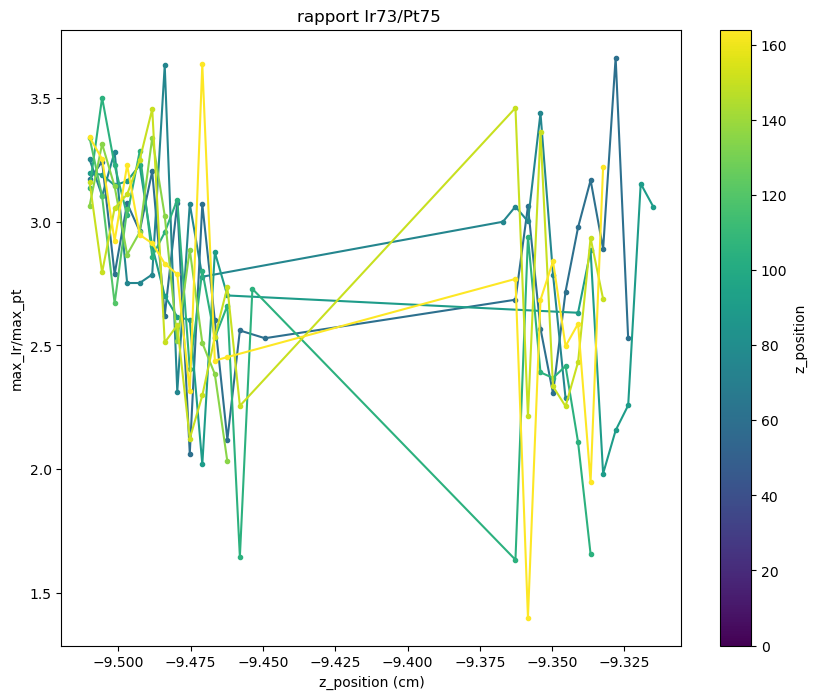

In [13]:

data = open_data ("/home/esrf/pauline2a/ma6562/id31/20250509/RAW_DATA/X1/","ma6562_X1.h5", "/measurement/fx_det0/","/measurement/epoch/" ,"/measurement/h1tz/", "/measurement/srcur/" )
data_baselines = data_baseline ("/home/esrf/pauline2a/ma6562/id31/20250509/RAW_DATA/X1/","ma6562_X1.h5", "/measurement/fx_det0/","/measurement/epoch/" ,"/measurement/h1tz/","/measurement/srcur/")
# keys = data_baselines.keys()
keys = []
scan_numb_red = []
scan_names = data_baselines.keys ()
ordered_keys, scan_numb = arrange_keys(scan_names)
norm = mcolors.Normalize(vmin=0, vmax = (len (ordered_keys) -1))
cmap = cm.viridis
fig, ax = plt.subplots(figsize = (10,8) )
for i in range (50, len(ordered_keys),15):
    keys.append(ordered_keys[i])
    scan_numb_red.append (scan_numb[i]) 

for scan_numb, key in zip (scan_numb_red, keys) : 
    y= []
    if "Ir63" in data_baselines[key]:
        color = cmap(scan_numb / (len (ordered_keys)))
        max_line_Ir = np.max(data_baselines[key]["Ir73"]["y_corrected"], axis = 1)    
        max_line_pt = np.max(data_baselines[key]["Pt75"]["y_corrected"], axis = 1)
        test = max_line_Ir/max_line_pt
        # x = np.arange(0, len(test))
        x = data_baselines[key]["Pt75"]["z_position"]
        plt.plot(x, test, label = f"{key}",color=cmap(norm(scan_numb)),marker = "o", markersize = 3)
plt.title("rapport Ir73/Pt75 ")
plt.xlabel("z_position (cm)")
plt.ylabel("max_Ir/max_pt")
# plt.legend()
# plt.xlim(0, 15)
# plt.ylim(-0.4, 3)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
fig.colorbar(sm, ax=ax, label='z_position') 
sm.set_array([])

plt.show()   


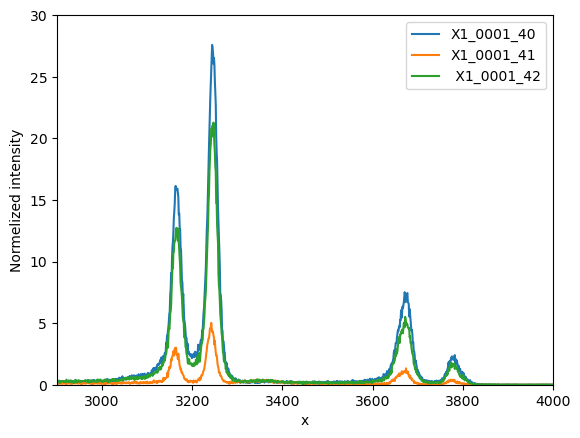

In [20]:
data = open_data ("/home/esrf/pauline2a/ma6562/id31/20250509/RAW_DATA/X1/","ma6562_X1.h5", "/measurement/fx_det0/","/measurement/epoch/" ,"/measurement/h1tz/", "/measurement/srcur/" )
y1 = data["X1_0001_40.1"]["XRF"][2]
y2 = data["X1_0001_41.1"]["XRF"][2]
y3 = data["X1_0001_42.1"]["XRF"][2]
y = [y1, y2, y3] 
scan_name =[ "X1_0001_40", "X1_0001_41"," X1_0001_42"]
x = list(range (0, 4096,1))
plt.subplots()
for i, j in  zip(scan_name,y) :
    plt.plot(x, j, label = f"{i}" )
plt.xlim(2900, 4000)
plt.ylim(0, 30)
plt.legend()
plt.xlabel("x")
plt.ylabel ("Normelized intensity")

plt.show()